# Assignment 2
## Exploratory Data Analysis: Titanic Dataset

**Yegor Gariazha**

**Dataset** Titanic — Machine Learning from Disaster   
**Source** https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv 

---

### Objective
Practice the core data analyst mindset: examine real data, identify quality issues, calculate statistics, and extract meaningful insights — just like analysts do in real projects.


---
## 0. Setup & Imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

---
## 1. Dataset Description

The **Titanic dataset** contains information about 891 passengers aboard the RMS Titanicю



In [3]:
# ── Load dataset ───────────────────────────────────────────────────────────
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df  = pd.read_csv(url)

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Shape: 891 rows × 12 columns


In [4]:
# ── Preview ────────────────────────────────────────────────────────────────
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# ── Column overview ────────────────────────────────────────────────────────
print(f"\nNumber of Rows and Columns: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Number of Rows and Columns: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


### Column Descriptions

| Column | Type | Description |
|---|---|---|
| `PassengerId` | Numeric (ID) | Unique identifier for each passenger |
| `Survived` | Binary (0/1) | **Target variable** — 0 = did not survive, 1 = survived |
| `Pclass` | Ordinal (1/2/3) | Ticket class — 1st, 2nd, or 3rd |
| `Name` | Text | Full name of the passenger |
| `Sex` | Categorical | Gender: male or female |
| `Age` | Numeric | Age in years (177 missing values) |
| `SibSp` | Numeric | Number of siblings/spouses aboard |
| `Parch` | Numeric | Number of parents/children aboard |
| `Ticket` | Text | Ticket number |
| `Fare` | Numeric | Passenger fare in British pounds |
| `Cabin` | Text | Cabin number (687 missing — 77%) |
| `Embarked` | Categorical | Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton |


---
## 2. Data Quality Issues

Real datasets are never perfect. Here we systematically identify and handle every issue found.


In [6]:
# ── 2.1 Missing values ────────────────────────────────────────────────────
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicates
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Outlier check
print("\nAge Outlier Information:")
print(f"Minimum Age: {df['Age'].min()}")
print(f"Maximum Age: {df['Age'].max()}")



Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows:
0

Age Outlier Information:
Minimum Age: 0.42
Maximum Age: 80.0


In [7]:
# ── 2.3 Handle issues ─────────────────────────────────────────────────────
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: too sparse — drop column, not usable
df.drop(columns=['Cabin'], inplace=True)
print('Cabin column dropped due to huge amount of missing values.')

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

Cabin column dropped due to huge amount of missing values.

Remaining missing values: 0


### Summary of Data Quality Issues

| Issue | Column(s) | Finding | Resolution |
|---|---|---|---|
| Missing values | `Age` | 177 missing  | Filled with column median (28.0) |
| Missing values | `Cabin` | 687 missing  | Column dropped — too sparse to use |
| Missing values | `Embarked` | 2 missing  | Filled with mode (Southampton) |
| Duplicates | All columns | 0 exact duplicates | No action needed |
| Outliers | `Age` | 1 passenger aged 80 | Kept — plausible age |


---
## 3. Basic Statistics


In [8]:
print("\nAge Statistics")
print(f"Mean Age: {df['Age'].mean():.2f}")
print(f"Median Age: {df['Age'].median():.2f}")
print(f"Min Age: {df['Age'].min()}")
print(f"Max Age: {df['Age'].max()}")

print("\nFare Statistics")
print(f"Mean Fare: {df['Fare'].mean():.2f}")
print(f"Median Fare: {df['Fare'].median():.2f}")
print(f"Min Fare: {df['Fare'].min()}")
print(f"Max Fare: {df['Fare'].max()}")

print("\nGender Counts")
print(df["Sex"].value_counts())

print("\nPassenger Class Counts")
print(df["Pclass"].value_counts())


Age Statistics
Mean Age: 29.36
Median Age: 28.00
Min Age: 0.42
Max Age: 80.0

Fare Statistics
Mean Fare: 32.20
Median Fare: 14.45
Min Fare: 0.0
Max Fare: 512.3292

Gender Counts
Sex
male      577
female    314
Name: count, dtype: int64

Passenger Class Counts
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


---
## 4. Insights Supported by Charts


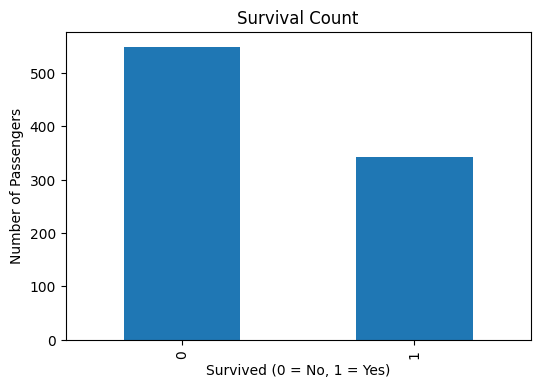

Overall survival rate: 38.4%


In [55]:
# ── Chart 1: Survival Count ───────────────────────────────────────────────
plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

print(f'Overall survival rate: {df["Survived"].mean()*100:.1f}%')

**Insight:** Only **38.4%** of passengers survived. The majority (61.6%) did not survive the sinking.

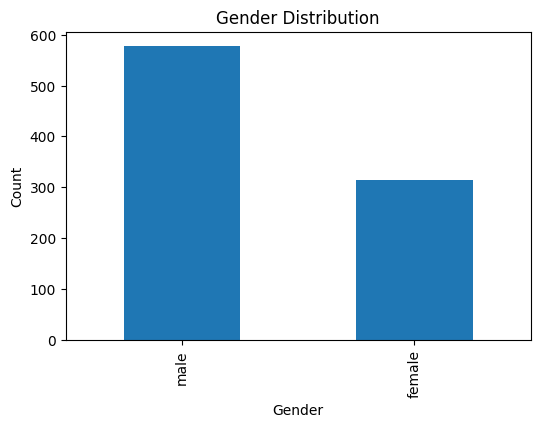

In [56]:
# ── Chart 2: Gender Distribution ───────────────────────────────────────────────
plt.figure(figsize=(6,4))
df["Sex"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

**Insight:** Female passengers had a more survival rate than males — reflecting the "women and children first" evacuation policy.

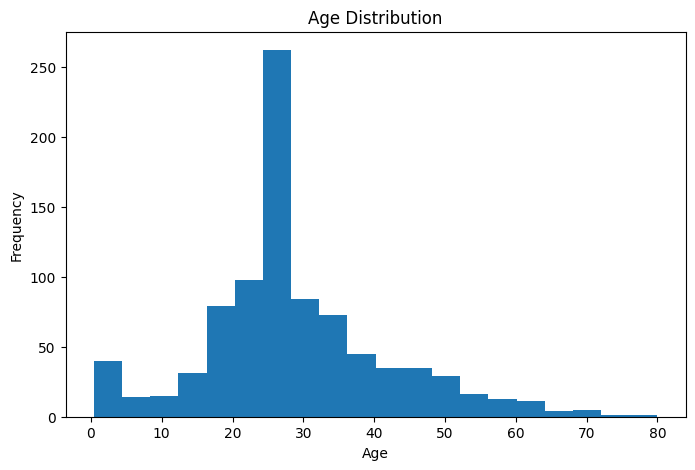

In [57]:
# ── Chart 3: Age Distribution ───────────────────────────────────────────────
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Insight:** Most passengers were between **20 and 40 years old**. There is also a small spike of very young children (under 5), indicating families traveling together.

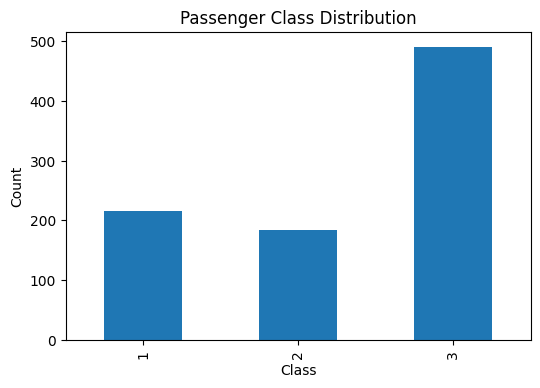

In [58]:
# ── Chart 4: Passenger Class Distribution ────────────────────────────────
plt.figure(figsize=(6,4))
df["Pclass"].value_counts().sort_index().plot(kind="bar")
plt.title("Passenger Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

**Insight:** **3rd class** had the most passengers, more than **1st** and **2nd** combined — yet as we'll see, **3rd** class had the lowest survival rate.

Text(0, 0.5, 'Survival Rate (%)')

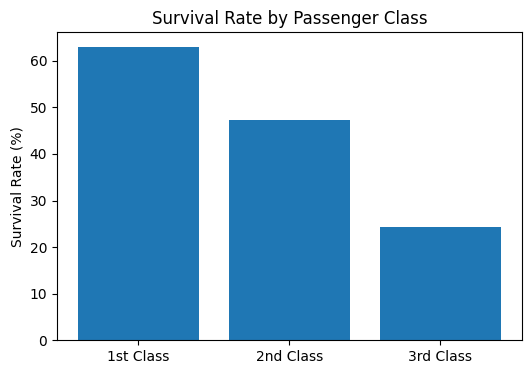

In [9]:
surv_class = df.groupby('Pclass')['Survived'].mean()

pclass_labels = ['1st Class', '2nd Class', '3rd Class']

plt.figure(figsize=(6,4))

plt.bar(pclass_labels, surv_class.values * 100)

plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate (%)')

**Insight:** 1st class passengers survived more often than other classes, while 3rd class passengers survived the least. This shows a clear difference between passenger classes, likely influenced by their location on the ship and access to lifeboats.

---
## 5. Final Conclusion

This exploratory analysis of 891 Titanic passengers reveals clear patterns in who survived the disaster:

| Finding | Detail |
|---|---|
| Overall survival rate | 38.4% of passengers survived |
| Gender effect | Female passengers had a more survival rate than males |
| Class effect | 1st class passengers survived more often than other classes, while 3rd class passengers survived the least. |
| Age | Most passengers were 20–40 years old |
| Fare distribution | Heavily right-skewed — most paid modest fares; a few 1st-class passengers paid extremely high fares |

**Key takeaways:**

1. **Gender was the strongest predictor of survival** — the "women and children first" policy had a dramatic real-world effect.
2. **Wealth (passenger class) also strongly influenced survival** — 1st class passengers had better access to lifeboats due to their cabin locations.
3. **Data cleaning was necessary before analysis** — Age had 177 missing values, Cabin had 687 and was dropped entirely, and Embarked had 2 missing values.

A natural next step would be building a **classification model** to predict survival, using `Sex`, `Pclass`, `Age`, and `Fare` as features — all variables that showed strong relationships with the target in this EDA.
